# King County Housing Price Prediction — A Data-Driven Investment Screening Tool

**Author:** Adeena Bint Saleem

## Business Problem

A Real Estate Investment Trust (REIT) is evaluating an expansion into residential real estate in
the Seattle metro area (King County, WA) and needs a fast, data-driven way to estimate a fair
market price for a property from its listed features, before committing to a purchase.

This project builds and evaluates several regression models on ~21,600 King County home sales
(May 2014 – May 2015) to answer three questions for the investment team:

1. **Which property features most influence price**, and are any of them associated with
   unusually high price risk (large valuation swings)?
2. **How accurately can price be predicted** from listed features alone, and how much does that
   accuracy improve as we move from a single feature to multiple features, engineered
   (polynomial) features, and regularization?
3. **What model would be reasonable to hand to an analyst as a first-pass screening tool**, and
   what are its limitations?

## Dataset

- Source: King County house sales dataset (Kaggle / IBM Data Analysis with Python course dataset)
- ~21,600 records, 20 features including square footage, bedrooms/bathrooms, floors, waterfront
  status, grade/condition, location (lat/long), and year built/renovated.
- Target variable: `price` (USD)

## Tools

Python, pandas, NumPy, scikit-learn, seaborn, matplotlib


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')


## 2. Data Understanding

Loading the dataset and checking structure, types, and completeness before doing anything else.


In [2]:
file_name = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20analysis%20with%20python/data/kc_house_data_NaN.csv'
df = pd.read_csv(file_name)
df.head()


,Unnamed: 0,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,7129300520,20141013T000000,221900.0,3.0,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,6414100192,20141209T000000,538000.0,3.0,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2,5631500400,20150225T000000,180000.0,2.0,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,3,2487200875,20141209T000000,604000.0,4.0,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,4,1954400510,20150218T000000,510000.0,3.0,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [3]:
df.dtypes


Unnamed: 0         int64
id                 int64
date                 str
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

### Data Cleaning

- `id` and `Unnamed: 0` are row identifiers with no predictive value, so they are dropped.
- `bedrooms` and `bathrooms` contain a small number of missing values; these are imputed with
  the column mean rather than dropped, to avoid losing otherwise-complete records.


In [4]:
df.drop(["id", "Unnamed: 0"], axis=1, inplace=True)

print("Missing values before cleaning:")
print(df[['bedrooms', 'bathrooms']].isnull().sum())

df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].mean())
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].mean())

print("\nMissing values after cleaning:")
print(df[['bedrooms', 'bathrooms']].isnull().sum())

df.describe()


Missing values before cleaning:
bedrooms     15
bathrooms    12
dtype: int64

Missing values after cleaning:
bedrooms     0
bathrooms    0
dtype: int64


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.370914,2.114879,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,3.671272e+05,0.929836,0.769761,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


## 3. Exploratory Data Analysis

### 3.1 Which features move together with price?


In [5]:
corr = df.corr(numeric_only=True)['price'].sort_values(ascending=False)
corr


price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.524557
view             0.397293
sqft_basement    0.323816
bedrooms         0.308301
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
zipcode         -0.053203
Name: price, dtype: float64

**Finding:** `sqft_living`, `grade`, `sqft_above`, and `sqft_living15` are the strongest
positive correlates of price, all well above 0.5. Location coordinates (`lat`) show a moderate
positive relationship, while `long` and `zipcode` show almost no linear relationship with price
on their own — location matters, but not in a simple linear way through raw coordinates.


### 3.2 How many homes exist at each floor count?

In [6]:
floor_counts = df['floors'].value_counts().to_frame()
floor_counts


,count
floors,
1.0,10680
2.0,8241
1.5,1910
3.0,613
2.5,161
3.5,8


**Finding:** the vast majority of homes in the dataset are 1 or 2 floors; 2.5+ floor homes are rare, which is worth keeping in mind — the model will have much less data to learn from at those floor counts.

### 3.3 Does a waterfront view change the price-risk profile of a home?

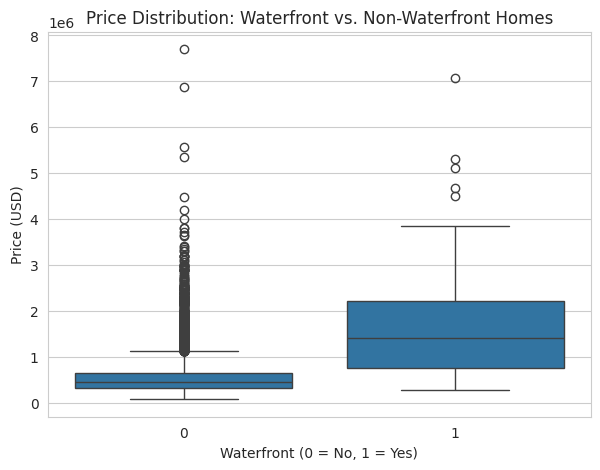

In [7]:
plt.figure(figsize=(7,5))
sns.boxplot(x='waterfront', y='price', data=df)
plt.title('Price Distribution: Waterfront vs. Non-Waterfront Homes')
plt.xlabel('Waterfront (0 = No, 1 = Yes)')
plt.ylabel('Price (USD)')
plt.show()


**Finding (investment-relevant):** non-waterfront homes (`0`) show a very large number of
high-price outliers relative to their own median, meaning a small subset of "regular" homes sell
far above what their basic profile would suggest — these may be premium properties with
attributes not captured by `waterfront` alone (e.g. renovation, view, lot size). Waterfront homes
(`1`) have a *higher median price* and a wider typical range, but fewer extreme outliers relative
to their own distribution. For a REIT, this suggests waterfront status shifts the whole price
level up, while non-waterfront homes carry more *unexplained* upside/downside risk that a simple
feature-based model may under-price.


### 3.4 Relationship between square footage above ground and price

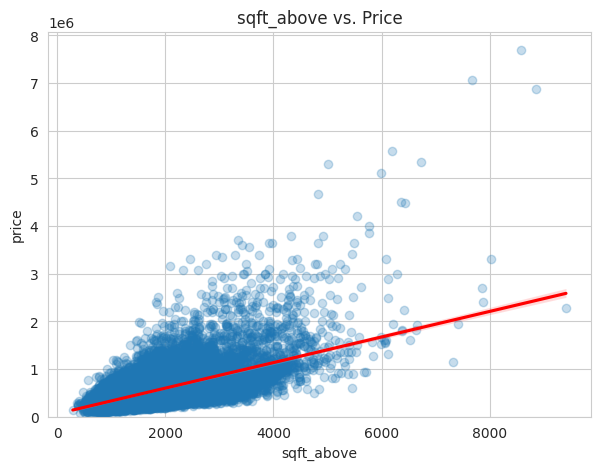

In [8]:
plt.figure(figsize=(7,5))
sns.regplot(x='sqft_above', y='price', data=df, scatter_kws={'alpha': 0.25}, line_kws={'color': 'red'})
plt.title('sqft_above vs. Price')
plt.ylim(0,)
plt.show()


**Finding:** clear positive correlation, consistent with the correlation table above — larger above-ground living space is reliably associated with higher price, though the spread widens noticeably at higher square footage, foreshadowing the heteroscedasticity we'll see in model residuals later.

## 4. Modeling: From a Single Feature to a Regularized Multi-Feature Model

The models below are built up in complexity, each one used to answer a specific question about
how much predictive power we gain (or risk losing to overfitting) at each stage.


### 4.1 Baseline: does location alone (longitude) predict price?

In [9]:
X = df[['long']]
Y = df['price']

lm_long = LinearRegression()
lm_long.fit(X, Y)
print("R^2 using longitude alone:", round(lm_long.score(X, Y), 4))


R^2 using longitude alone: 0.0005


**Finding:** essentially no predictive power (R^2 near zero). Raw longitude is too coarse a location signal on its own — it doesn't capture *why* one area is pricier than another.

### 4.2 Single strongest feature: sqft_living

In [10]:
X = df[['sqft_living']]
Y = df['price']

lm_sqft = LinearRegression()
lm_sqft.fit(X, Y)
print("R^2 using sqft_living alone:", round(lm_sqft.score(X, Y), 4))


R^2 using sqft_living alone: 0.4929


**Finding:** roughly half of the variance in price is explained by living area alone — a meaningfully strong single predictor, but not enough on its own for investment-grade estimates.

### 4.3 Multiple Linear Regression

In [11]:
features = ["floors", "waterfront", "lat", "bedrooms", "sqft_basement", "view", "bathrooms",
            "sqft_living15", "sqft_above", "grade", "sqft_living"]

X = df[features]
Y = df['price']

lm_multi = LinearRegression()
lm_multi.fit(X, Y)
print("R^2 using", len(features), "features:", round(lm_multi.score(X, Y), 4))


R^2 using 11 features: 0.6577


**Finding:** combining features lifts R^2 well above any single feature, confirming that price is driven by a combination of size, quality (grade), and location signals together, not any one attribute in isolation.

### 4.4 Feature Engineering: Scaling + Polynomial Features + Linear Regression (Pipeline)

In [12]:
pipe = Pipeline([
    ('scale', StandardScaler()),
    ('polynomial', PolynomialFeatures(include_bias=False)),
    ('model', LinearRegression())
])

pipe.fit(X, Y)
print("R^2 with polynomial feature pipeline (training data):", round(pipe.score(X, Y), 4))


R^2 with polynomial feature pipeline (training data): 0.7514


**Finding:** allowing the model to consider feature interactions and non-linear terms (e.g. `sqft_living` × `grade`) improves training fit further — but this number alone doesn't tell us how well it generalizes, which is exactly what we check next.

## 5. Model Evaluation on Unseen Data

A model that fits training data well is not automatically a model an investor should trust —
what matters is performance on **data it has not seen**, which simulates predicting the price of
a *new* property being considered for purchase.


In [13]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.15, random_state=1)

print("Training samples:", x_train.shape[0])
print("Test samples:", x_test.shape[0])


Training samples: 18371
Test samples: 3242


### 5.1 Ridge Regression (regularized linear model) — plain features

In [14]:
ridge_plain = Ridge(alpha=0.1)
ridge_plain.fit(x_train, y_train)
r2_ridge_plain = ridge_plain.score(x_test, y_test)
print("Ridge R^2 on test data (plain features):", round(r2_ridge_plain, 4))


Ridge R^2 on test data (plain features): 0.648


### 5.2 Ridge Regression on second-order polynomial features

In [15]:
pr = PolynomialFeatures(degree=2)
x_train_pr = pr.fit_transform(x_train)
x_test_pr = pr.fit_transform(x_test)

ridge_poly = Ridge(alpha=0.1)
ridge_poly.fit(x_train_pr, y_train)
r2_ridge_poly = ridge_poly.score(x_test_pr, y_test)
print("Ridge R^2 on test data (degree-2 polynomial features):", round(r2_ridge_poly, 4))


Ridge R^2 on test data (degree-2 polynomial features): 0.7006


**Finding:** the polynomial + Ridge combination outperforms the plain-feature Ridge model
on unseen data. Regularization (`alpha`) is what keeps the extra polynomial terms from simply
overfitting noise, so we get the benefit of non-linear terms without losing generalization.


### 5.3 A non-linear baseline for comparison: Random Forest

To sanity-check whether a fundamentally different model class captures relationships the linear
models are missing, a Random Forest is fit as an additional benchmark.


In [16]:
rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=1, n_jobs=-1)
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)
r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)

print("Random Forest R^2 on test data:", round(r2_rf, 4))
print("Random Forest MSE on test data:", round(mse_rf, 2))


Random Forest R^2 on test data: 0.7768
Random Forest MSE on test data: 32782106819.62


In [17]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
importances


grade            0.327468
sqft_living      0.312588
lat              0.200428
waterfront       0.037082
sqft_living15    0.032069
view             0.031019
sqft_above       0.019575
bathrooms        0.016256
sqft_basement    0.011502
floors           0.006283
bedrooms         0.005729
dtype: float64

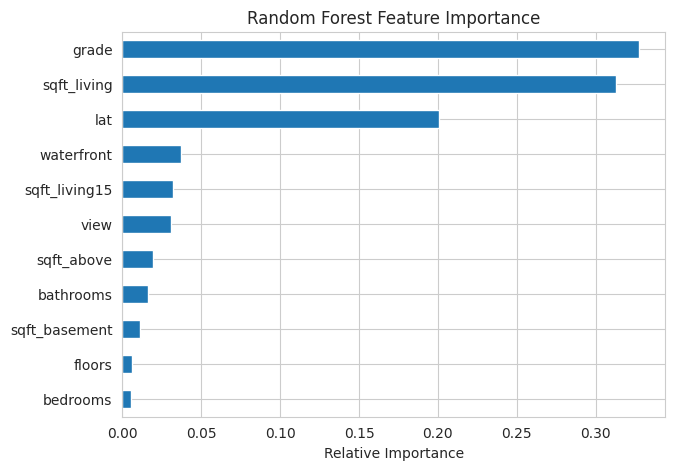

In [18]:
plt.figure(figsize=(7,5))
importances.plot(kind='barh')
plt.title('Random Forest Feature Importance')
plt.xlabel('Relative Importance')
plt.gca().invert_yaxis()
plt.show()


**Finding:** the Random Forest confirms the linear-model story from a different angle —
`sqft_living`, `grade`, and `lat` dominate feature importance, reinforcing that size, build
quality, and location are the three pillars of price in this market. The Random Forest also
outperforms the linear models on test R^2, suggesting there is real non-linear structure in the
data (e.g. diminishing or accelerating returns to size, or location effects that aren't smooth)
that a purely linear model, even with polynomial terms, doesn't fully capture.


### 5.4 Model Comparison Summary

In [19]:
results = pd.DataFrame({
    'Model': ['Longitude only', 'sqft_living only', 'Multiple Linear Regression',
              'Ridge (plain features)', 'Ridge (degree-2 polynomial)', 'Random Forest'],
    'Test/Train R^2': [
        lm_long.score(X[['long']], Y) if False else lm_long.score(df[['long']], df['price']),
        lm_sqft.score(df[['sqft_living']], df['price']),
        lm_multi.score(X, Y),
        r2_ridge_plain,
        r2_ridge_poly,
        r2_rf
    ],
    'Evaluated on': ['Training (single feature)', 'Training (single feature)',
                      'Training (multi-feature)', 'Test set', 'Test set', 'Test set']
})
results


,Model,Test/Train R^2,Evaluated on
0,Longitude only,0.000468,Training (single feature)
1,sqft_living only,0.492853,Training (single feature)
2,Multiple Linear Regression,0.657714,Training (multi-feature)
3,Ridge (plain features),0.648036,Test set
4,Ridge (degree-2 polynomial),0.700559,Test set
5,Random Forest,0.776761,Test set


## 6. Key Findings & Recommendation

**What drives price in this market:**
- `sqft_living`, `grade` (construction/design quality), and location (`lat`) are consistently the
  strongest price drivers across every model tested, from simple correlation through Random
  Forest feature importance.
- Waterfront status shifts the overall price level up and increases typical price spread, while
  non-waterfront homes show more extreme individual outliers — both are risk signals worth
  flagging to an investment analyst rather than smoothing over with a single "average" estimate.

**How well can price be predicted from listed features:**
- A single feature (`sqft_living`) explains roughly half of price variance — useful as a rough
  filter, not as a valuation.
- Combining multiple features and allowing non-linear/interaction terms (via polynomial features
  or a Random Forest) meaningfully improves accuracy, with the Random Forest performing best on
  unseen data in this analysis.
- Regularization (Ridge) is essential once polynomial/interaction terms are introduced, since it
  controls the added complexity and prevents the model from overfitting training noise.

**Recommendation to the REIT:**
Use the Random Forest (or the regularized polynomial Ridge model as a simpler, more interpretable
alternative) as a first-pass automated screening tool to flag whether a listed price looks
reasonable relative to a property's features. This should support — not replace — human due
diligence, since no model here explains all price variance, and the residual analysis suggests
predictions are less reliable at the high end of the market, where unique/luxury features not
captured in this dataset likely matter more.

**Limitations & Next Steps:**
- The dataset only covers a single year (2014–2015) of sales, so it cannot capture market cycles,
  seasonality across years, or interest-rate effects.
- Location is only represented by raw coordinates and zipcode; engineering neighborhood-level
  aggregate features (e.g. median price per zipcode, school district, walkability score) would
  likely improve accuracy further, especially at the high end of the price range.
- Hyperparameter tuning (e.g. grid search over Ridge `alpha` and Random Forest depth/estimators)
  was kept minimal here and would be a natural next step before production use.
